In [1]:
import numpy as np    
import matplotlib.pyplot as plt
%matplotlib inline    
 
from fizinfo import *

In [ ]:
#Gy / 8. feladat [20 p]
# 
# Az órai anyagban tanult "rakéta modell" segítségével modellezze egy játék vízrakéta mozgását
# az alábbi paraméterekkel:
# 
# A rakéta üres tömege 0,1 kg, a hajtóanyag tömege 0,3 kg, a kiáramlás sebessége 35 m/s és a
# tömegáram 0,2 kg/s-os. A rakétatest sugara 3 cm, alaktényezője 0,2.
# 
# A rakétát 1 m magasról, a vízszintessel 85 fokos szöget bezáróan, 1 m/s sebességgel indítjuk.

# rakétamodell tömeg- és erőfüggvéye

In [ ]:
def create_rocket_F_m(C, A, rho, szaraz_tomeg, hajtoanyag_tomeg, kiaramlasi_seb,
                          tomegaram, g=9.81):
    """
    Visszaadja a rakéta erő- és tömegfüggvényét.

    Paraméterek:
        C                  : közegellenállási együttható (C_D)
        A                  : rakéta homlokfelülete [m²]
        rho                : levegő sűrűsége [kg/m³]
        szaraz_tomeg       : rakéta tömege hajtóanyag nélkül [kg]
        hajtoanyag_tomeg   : kezdeti hajtóanyag tömege [kg]
        kiaramlasi_seb     : hajtóanyag kilépési sebessége (hatásos) [m/s]
        tomegaram          : hajtóanyag fogyasztás [kg/s]
        g                  : gravitációs gyorsulás [m/s²]
    """

    def tomeg_fuggveny(t):
        # Teljes rakétatömeg az idő függvényében:
        # lineárisan csökken (szaraz_tomeg + hajtoanyag_tomeg)-ről,
        # de szaraz_tomeg alá nem mehet (ha elfogyott a hajtóanyag)
        return np.maximum(szaraz_tomeg,
                          szaraz_tomeg + hajtoanyag_tomeg - tomegaram * t)

    def ero_fuggveny(t, helyzet, sebesseg, tomeg):
        """
        Az összes erő eredője [N], 2D vektorként (x, y).

        Hatások:
          - gravitáció (lefelé, y irányban)
          - közegellenállás (sebességgel ellentétes irányban, v²-tel arányos)
          - tolóerő (sebességgel megegyező irányban, amíg van hajtóanyag)
        """

        # --- Gravitációs erő ---
        eredo_ero = np.array([0.0, -tomeg * g], np.float64)  # [Fx, Fy], csak y irányú

        # --- Közegellenállási erő ---
        sebesseg_nagysag = ((sebesseg ** 2).sum()) ** 0.5          # sebesség abszolút értéke [m/s]
        eredo_ero -= 0.5 * C * A * rho \
                     * sebesseg * sebesseg_nagysag                 # F_légellenállás = ½·C·A·ρ·v·|v|

        # --- Tolóerő ---
        toloeroe_nagyság = tomegaram * kiaramlasi_seb              # F_t = ṁ · v_kilépő [N]
        hajtasi_ido = hajtoanyag_tomeg / tomegaram                  # meddig ég a hajtóanyag [s]

        if t <= hajtasi_ido:                                       # még van hajtóanyag
            eredo_ero += toloeroe_nagyság * sebesseg / np.maximum(sebesseg_nagysag, 1e-10)
            # irány: normált sebességvektor (1e-10 védi a nullával való osztástól)

        return eredo_ero

    return ero_fuggveny, tomeg_fuggveny

# --- Rakéta fizikai paraméterei ---
szaraz_tomeg       = 0.1   # rakéta tömege hajtóanyag nélkül [kg]
hajtoanyag_tomeg   = 0.3   # kezdeti hajtóanyag tömege [kg]
kiaramlasi_seb     = 35.0  # hajtóanyag hatásos kilépési sebessége [m/s]
tomegaram          = 0.2   # hajtóanyag fogyasztási sebesség [kg/s]

# --- Aerodinamikai paraméterek ---
test_sugar     = 0.03                    # rakétatest sugara [m] (3 cm)
A              = np.pi * test_sugar**2   # homlokfelület területe [m²]
C              = 0.2                     # közegellenállási együttható (alaktényező)
rho            = 1.3                     # levegő sűrűsége [kg/m³]

# --- Erő- és tömegfüggvény példányosítása ---
ero_fuggveny, tomeg_fuggveny = create_rocket_F_m(
    C, A, rho,
    szaraz_tomeg, hajtoanyag_tomeg, kiaramlasi_seb,
    tomegaram, g=9.81
)

# --- Kezdőfeltételek ---
indulo_sebesseg = 1.0   # kezdeti sebesség nagysága [m/s]
indulo_szog_fok = 85.0  # indulási szög vízszintestől mérve [°]

kezdo_x = 0.0  # kezdeti x pozíció [m]
kezdo_y = 1.0  # kezdeti y pozíció [m] (1 m magasról indítjuk)

# Sebességvektor felbontása x és y komponensre a szög alapján:
kezdo_vx = indulo_sebesseg * np.cos(np.radians(indulo_szog_fok))  # vízszintes sebesség [m/s]
kezdo_vy = indulo_sebesseg * np.sin(np.radians(indulo_szog_fok))  # függőleges sebesség [m/s]

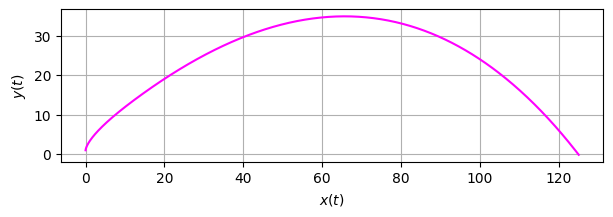

In [3]:
# a) Rajzolja fel a vízrakéta pályáját a földbe csapódásig! (3 p)

# --- Leállási feltétel: szimuláció megáll, ha a rakéta eléri a talajt ---
def stop_ground_y(r, v):
    """
    Leállási feltétel a numerikus integrátornak.
    Visszatér True-val (→ stop), ha a rakéta y koordinátája negatív,
    azaz átment a talajon (y = 0 szint).
    
    Paraméterek:
        r : helyvektor [x, y] [m]
        v : sebességvektor [vx, vy] [m/s]
    """
    return r[1] < 0.0

# --- Numerikus dinamikai szimuláció összeállítása ---
rocket_din = num_dinam(2)                             # 2D mozgás (x-y sík)
rocket_din.set_time_range(0.0, 100.0, 0.01)          # t ∈ [0, 100] s, dt = 0,01 s
                                                      # (100 s bőven elég – a stop feltétel
                                                      #  hamarabb leállítja az integrációt)
rocket_din.set_F_fun(ero_fuggveny)                   # erőfüggvény (gravitáció + drag + tolóerő)
rocket_din.set_mass_fun(tomeg_fuggveny)              # tömegfüggvény (hajtóanyag-fogyás)
rocket_din.set_r0_v0([kezdo_x, kezdo_y],             # kezdeti helyzet:  [0 m, 1 m]
                     [kezdo_vx, kezdo_vy])            # kezdeti sebesség: 85°, 1 m/s

rocket_din.stop_cond = stop_ground_y                 # leállási feltétel regisztrálása

# --- Integráció futtatása ---
rocket_din.full_dinam_calc()                         # numerikus integráció (pl. RK4)

# --- Pályagörbe megjelenítése ---
rocket_din.plot_rcomp(figsize=(7, 7))                # x(t) és y(t) komponensek külön ábrán

## koordináták az iodő függvényében
#rocket_din.plot_rva_coord()
#
## sebesség nagysága az idő függvényében
#rocket_din.vabs=vect_abs(rocket_din.v)
#rocket_din.plot_simple([rocket_din.vabs])
#
## gyorsulás nagysága az idő függvényében
#rocket_din.aabs=vect_abs(rocket_din.a)
#rocket_din.plot_simple([rocket_din.aabs])

In [4]:

# b) Mekkora a mozgás során a rakéta teljes útja és elmozdulásának nagysága (2 p)

# A teljes út és az elmozdulás nem ugyanaz.
# - teljes út: a pálya görbéje mentén bejárt ívhossz
# - elmozdulás: a végpont és a kezdőpont közötti egyenes vektor hossza

rocket_din.calc_pathlength()  # a szomszédos pontok közötti kis útdarabokat összegzi

# A pathlength tömb utolsó eleme az indulástól a becsapódásig megtett teljes út.
teljes_ut = rocket_din.pathlength[-1]

# Az elmozdulásvektor: véghelyzet - kezdőhelyzet.
# Fontos, hogy nem az origótól vett utolsó távolságot számoljuk,
# hanem azt, mennyit mozdult el a rakéta a saját indulási pontjához képest.
elmozdulas_vektor = rocket_din.r[-1] - rocket_din.r[0]
elmozdulas_nagysag = np.sqrt((elmozdulas_vektor**2).sum())

print(f'A mozgás során megtett teljes út: {teljes_ut:.2f} m.')
print(f'A mozgás során az elmozdulás nagysága: {elmozdulas_nagysag:.2f} m.')


A mozgás során megtett teljes út: 147.87 m.
A mozgás során az elmozdulás nagysága: 125.01 m.


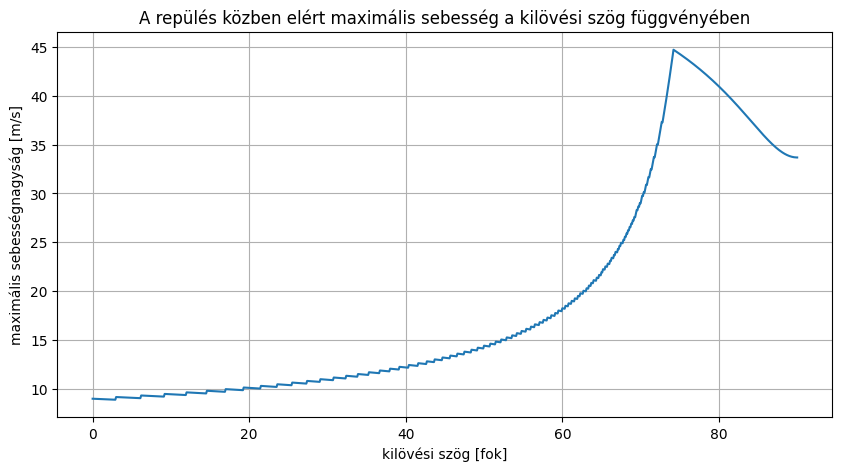

In [5]:

# c) Ábrázolja grafikonon a kilövési szög függvényében a repülés közben elért maximális sebesség
# nagyságát. A kilövési szögön kívül a többi paraméter nem változik. (4 p)

# Ugyanazt a rakétamodellt sokszor kell lefuttatni, mindig más kilövési szöggel.
# Ezért készítünk egy segédfüggvényt. A függvény egy adott szögre:
# 1. kiszámolja a kezdősebesség komponenseit,
# 2. létrehoz egy új num_dinam objektumot,
# 3. lefuttatja a mozgást a földbe csapódásig,
# 4. eltárolja a sebességnagyságot.

def raketa_szimulacio(szog_fok, dt=0.01, t_max=100.0):
    # A kezdősebesség nagysága minden szögnél ugyanaz, csak az x-y komponensek változnak.
    vx0 = indulo_sebesseg * np.cos(np.radians(szog_fok))
    vy0 = indulo_sebesseg * np.sin(np.radians(szog_fok))
    
    # Minden szöghöz új objektumot készítünk, hogy a korábbi futások ne keveredjenek bele.
    raketa = num_dinam(2)
    raketa.set_time_range(0.0, t_max, dt)
    raketa.set_F_fun(ero_fuggveny)
    raketa.set_mass_fun(tomeg_fuggveny)
    raketa.set_r0_v0([kezdo_x, kezdo_y], [vx0, vy0])
    raketa.stop_cond = stop_ground_y
    
    # Teljes dinamikai számítás a becsapódásig.
    raketa.full_dinam_calc()
    
    # Sebességnagyság, mert a feladat maximumsebességet kér.
    raketa.v_abs = vect_abs(raketa.v)
    return raketa


# A kilövési szögeket 0 és 90 fok között vizsgáljuk.
# A 0.1 fokos felbontás elég részletes ahhoz, hogy jól látszódjon a maximum helye.
szogek = np.arange(0.0, 90.0 + 0.1, 0.1)
max_sebessegek = []

for szog in szogek:
    raketa = raketa_szimulacio(szog)
    
    # A num_dinam a leálláskor az első talaj alatti pontot is eltárolhatja.
    # A "repülés közben" kifejezéshez ezért csak a y >= 0 pontokon nézzük a sebességet.
    repulesben = raketa.r[:, 1] >= 0.0
    max_sebessegek.append(raketa.v_abs[repulesben].max())

max_sebessegek = np.array(max_sebessegek)

fig = plt.figure(figsize=(10, 5))
ax1 = plt.subplot(111)

ax1.plot(szogek, max_sebessegek)
ax1.set_xlabel('kilövési szög [fok]')
ax1.set_ylabel('maximális sebességnagyság [m/s]')
ax1.set_title('A repülés közben elért maximális sebesség a kilövési szög függvényében')
ax1.grid()


A vizsgált szögek közül a legnagyobb maximális sebesség 74.2 foknál adódik.
Ennek értéke: 44.71 m/s.


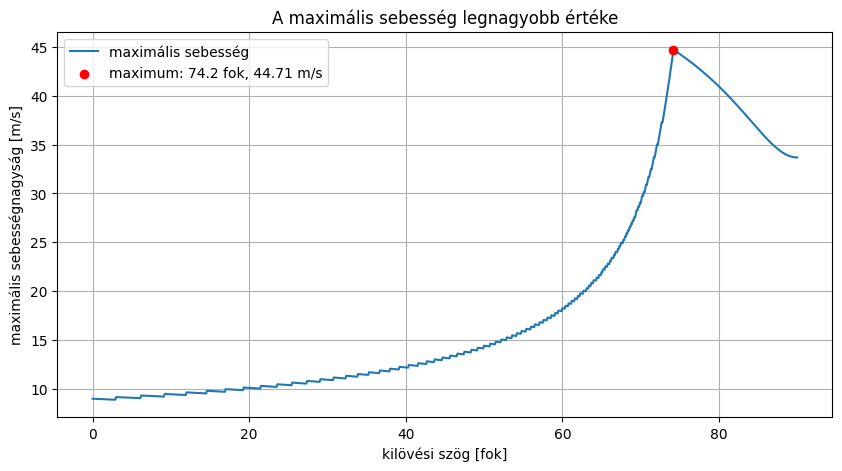

In [6]:

# d) Milyen kilövési szög mellett lenne maximális az előző pontbeli sebesség és mennyi ennek
# értéke (3 p)

# Az előző cellában kiszámoltuk minden vizsgált szöghöz a repülés közbeni maximális sebességet.
# Most megkeressük, melyik szögnél lett ez a legnagyobb.

idx_max = max_sebessegek.argmax()
optimalis_szog = szogek[idx_max]
optimalis_max_sebesseg = max_sebessegek[idx_max]

print(f'A vizsgált szögek közül a legnagyobb maximális sebesség {optimalis_szog:.1f} foknál adódik.')
print(f'Ennek értéke: {optimalis_max_sebesseg:.2f} m/s.')

# Ugyanezt ábrán is bejelöljük, hogy a maximum helye vizuálisan is egyértelmű legyen.
fig = plt.figure(figsize=(10, 5))
ax1 = plt.subplot(111)

ax1.plot(szogek, max_sebessegek, label='maximális sebesség')
ax1.scatter([optimalis_szog], [optimalis_max_sebesseg], color='red', zorder=3,
            label=f'maximum: {optimalis_szog:.1f} fok, {optimalis_max_sebesseg:.2f} m/s')

ax1.set_xlabel('kilövési szög [fok]')
ax1.set_ylabel('maximális sebességnagyság [m/s]')
ax1.set_title('A maximális sebesség legnagyobb értéke')
ax1.legend()
ax1.grid()


In [9]:

# e) Egy olyan épület felett szeretnénk átlőni, melynek magassága 20 m és a lövés irányában 40 m
# hosszú. Milyen messze lehet a kilövés helye az épülettől, ha a kilövési szög az eredeti 85 fok (8 p)

# Az épületet a lövés irányában értelmezzük, tehát az x tengely mentén van 40 m hosszan.
# Ha az épület eleje d távolságra van a kilövési ponttól, akkor az épület az x = d ... d+40 m
# intervallumot foglalja el. Az átlövés feltétele, hogy ezen az egész intervallumon
# a rakéta magassága legalább 20 m legyen.

# Újraszámoljuk az eredeti, 85 fokos pályát, hogy biztosan friss adatokkal dolgozzunk.
raketa85 = raketa_szimulacio(85.0)

epulet_magassag = 20.0
epulet_hossz = 40.0

# Megkeressük, hogy a pálya mely x-intervallumokon van legalább 20 m magasan.
magas_szakaszok = raketa85.x_ranges_above_height(epulet_magassag)

lehetseges_helyek = []

for x_start, x_end in magas_szakaszok:
    # Az épület akkor fér el a magas pályaszakasz alatt,
    # ha a 20 m feletti szakasz legalább olyan hosszú, mint az épület.
    if x_end - x_start >= epulet_hossz:
        min_tavolsag = x_start
        max_tavolsag = x_end - epulet_hossz
        lehetseges_helyek.append((min_tavolsag, max_tavolsag))

print(f"Az épület elejének minimális távolsága a kilövési ponttól: {min_tavolsag:.2f} m")
print(f"Az épület elejének maximális távolsága a kilövési ponttól: {max_tavolsag:.2f} m")


Az épület elejének minimális távolsága a kilövési ponttól: 21.39 m
Az épület elejének maximális távolsága a kilövési ponttól: 65.53 m
